In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1D Mixture Models

In [53]:
# We have the true parameters
MU1 = 3
MU2 = 5
VAR1 = 0.5
VAR2 = 1.5

In [54]:
# Let's create the sample data from the distributions (K=2)
dist1 = np.random.normal(loc=MU1, scale=VAR1, size=10)
dist2 = np.random.normal(loc=MU2, scale=VAR2, size=10)

In [55]:
dist1, dist2

(array([2.94519611, 2.939103  , 2.75370567, 3.03582102, 3.50212043,
        3.5695124 , 2.48484728, 2.30351084, 4.04373208, 3.9003432 ]),
 array([4.95568269, 2.46041628, 5.40127194, 5.37041291, 6.2226019 ,
        4.88484194, 6.14998468, 5.08838232, 5.91642844, 3.70339873]))

In [56]:
label1 = np.array([1 for _ in range(len(dist1))])
label2 = np.array([2 for _ in range(len(dist2))])

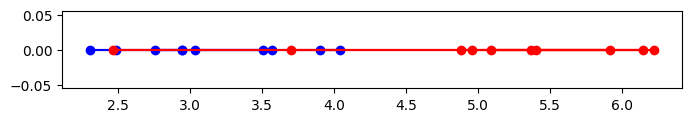

In [57]:
# Let's plot them
y = [0 for i in range(1,len(dist1)+1)]
plt.figure(figsize=(8,1))
plt.plot(dist1, y, color='blue', marker='o')
plt.plot(dist2, y, color='red', marker='o');

In [58]:
data = np.concat([dist1, dist2])
labels = np.concat([label1, label2])
data1 = pd.DataFrame(np.stack((data, labels), axis=1), columns=["values", "label"])
data1.head()

,values,label
0,2.945196,1.0
1,2.939103,1.0
2,2.753706,1.0
3,3.035821,1.0
4,3.502120,1.0


In [59]:
def normal_pdf(x, mean, var):
    return (1/((2*(22/7)*var)**0.5))*np.exp(-0.5*((x - mean)/(var))**2)

In [60]:
def bayes_theorem(cond_prob1, cond_prob2, prior = 0.5):
    return (cond_prob1*prior)/((cond_prob1*prior) + (cond_prob2*prior))

In [63]:
data1["bayes_probs"] = data1["values"].apply(
    func=lambda x: bayes_theorem(
        cond_prob1=normal_pdf(x=x, mean=MU1, var=VAR1),
        cond_prob2=normal_pdf(x=x, mean=MU2, var=VAR2),
        )
    )

In [65]:
data1["predictions"] = data1["bayes_probs"].apply(func=lambda x: 1 if x >= 0.5 else 2)

In [66]:
data1[["label", "predictions"]]

,label,predictions
0,1.0,1
1,1.0,1
2,1.0,1
3,1.0,1
4,1.0,1
5,1.0,1
6,1.0,1
7,1.0,1
8,1.0,2
9,1.0,2


In [68]:
pred1 = data1["values"][data1["predictions"] == 1]
pred2 = data1["values"][data1["predictions"] == 2]

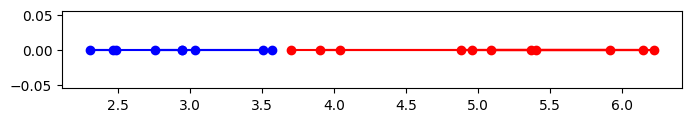

In [71]:
plt.figure(figsize=(8,1))
plt.plot(pred1, [0 for _ in range(len(pred1))], color="blue", marker="o")
plt.plot(pred2, [0 for _ in range(len(pred2))], color="red", marker="o");

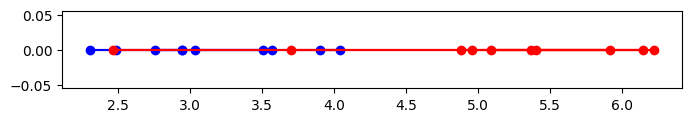

In [72]:
y = [0 for i in range(1,len(dist1)+1)]
plt.figure(figsize=(8,1))
plt.plot(dist1, y, color='blue', marker='o')
plt.plot(dist2, y, color='red', marker='o');